In [30]:
import kagglehub
path = kagglehub.competition_download('rsna-pneumonia-detection-challenge')
print(path)

/kaggle/input/competitions/rsna-pneumonia-detection-challenge


In [31]:
import os

base_path = '/kaggle/input/competitions/rsna-pneumonia-detection-challenge'
for item in os.listdir(base_path):
    full_path = os.path.join(base_path, item)
    if os.path.isdir(full_path):
        n_files = len(os.listdir(full_path))
        print(f"[DIR]  {item}  ({n_files} files)")
    else:
        size_mb = os.path.getsize(full_path) / (1024*1024)
        print(f"[FILE] {item}  ({size_mb:.2f} MB)")

[DIR]  stage_2_train_images  (26684 files)
[FILE] stage_2_sample_submission.csv  (0.15 MB)
[FILE] stage_2_detailed_class_info.csv  (1.57 MB)
[FILE] GCP Credits Request Link - RSNA.txt  (0.00 MB)
[FILE] stage_2_train_labels.csv  (1.42 MB)
[DIR]  stage_2_test_images  (3000 files)


In [32]:
import pandas as pd

train_labels = pd.read_csv(f'{base_path}/stage_2_train_labels.csv')
class_info = pd.read_csv(f'{base_path}/stage_2_detailed_class_info.csv')

print("train_labels shape:", train_labels.shape)
print(train_labels.head())
print()
print("class_info shape:", class_info.shape)
print(class_info.head())
print()
print("Target value counts:")
print(train_labels['Target'].value_counts())
print()
print("Class value counts:")
print(class_info['class'].value_counts())

train_labels shape: (30227, 6)
                              patientId      x      y  width  height  Target
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6    NaN    NaN    NaN     NaN       0
1  00313ee0-9eaa-42f4-b0ab-c148ed3241cd    NaN    NaN    NaN     NaN       0
2  00322d4d-1c29-4943-afc9-b6754be640eb    NaN    NaN    NaN     NaN       0
3  003d8fa0-6bf1-40ed-b54c-ac657f8495c5    NaN    NaN    NaN     NaN       0
4  00436515-870c-4b36-a041-de91049b9ab4  264.0  152.0  213.0   379.0       1

class_info shape: (30227, 2)
                              patientId                         class
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6  No Lung Opacity / Not Normal
1  00313ee0-9eaa-42f4-b0ab-c148ed3241cd  No Lung Opacity / Not Normal
2  00322d4d-1c29-4943-afc9-b6754be640eb  No Lung Opacity / Not Normal
3  003d8fa0-6bf1-40ed-b54c-ac657f8495c5                        Normal
4  00436515-870c-4b36-a041-de91049b9ab4                  Lung Opacity

Target value counts:
Target
0    20672
1     9555
Name: 

In [33]:
# Keep only one row per patient (since we only care about pneumonia yes/no, not location)
patient_labels = train_labels[['patientId', 'Target']].drop_duplicates()

print("Number of unique patients:", patient_labels.shape[0])
print(patient_labels['Target'].value_counts())

Number of unique patients: 26684
Target
0    20672
1     6012
Name: count, dtype: int64


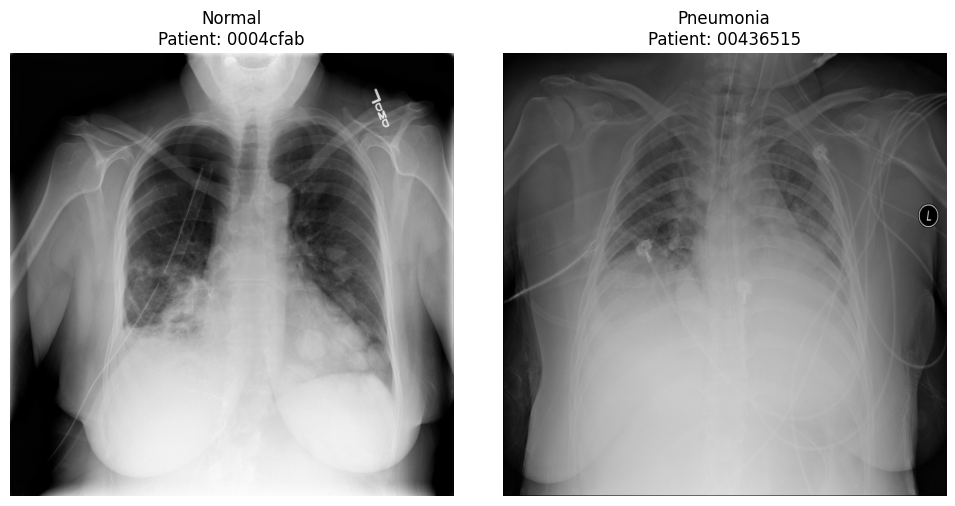

In [34]:
import pydicom
import matplotlib.pyplot as plt

# Pick one "Normal" (Target=0) and one "Pneumonia" (Target=1) patient
normal_id = patient_labels[patient_labels['Target'] == 0]['patientId'].iloc[0]
pneumonia_id = patient_labels[patient_labels['Target'] == 1]['patientId'].iloc[0]

# Load their DICOM files
normal_dcm = pydicom.dcmread(f'{base_path}/stage_2_train_images/{normal_id}.dcm')
pneumonia_dcm = pydicom.dcmread(f'{base_path}/stage_2_train_images/{pneumonia_id}.dcm')

# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(normal_dcm.pixel_array, cmap='gray')
axes[0].set_title(f'Normal\nPatient: {normal_id[:8]}')
axes[0].axis('off')

axes[1].imshow(pneumonia_dcm.pixel_array, cmap='gray')
axes[1].set_title(f'Pneumonia\nPatient: {pneumonia_id[:8]}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [35]:
import numpy as np

print("Normal image shape:", normal_dcm.pixel_array.shape)
print("Pneumonia image shape:", pneumonia_dcm.pixel_array.shape)
print("Normal image dtype:", normal_dcm.pixel_array.dtype)
print("Normal image min/max pixel values:", normal_dcm.pixel_array.min(), normal_dcm.pixel_array.max())

Normal image shape: (1024, 1024)
Pneumonia image shape: (1024, 1024)
Normal image dtype: uint8
Normal image min/max pixel values: 0 245


In [36]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp (which we'll split again)
train_df, temp_df = train_test_split(
    patient_labels,
    test_size=0.30,
    stratify=patient_labels['Target'],  # keeps the same class ratio in both groups
    random_state=42  # makes the split reproducible - same result every time we run it
)

# Second split: divide the 30% temp into validation (15%) and test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['Target'],
    random_state=42
)

print("Train:", train_df.shape[0], "| Pneumonia %:", (train_df['Target']==1).mean().round(3))
print("Val:  ", val_df.shape[0], "| Pneumonia %:", (val_df['Target']==1).mean().round(3))
print("Test: ", test_df.shape[0], "| Pneumonia %:", (test_df['Target']==1).mean().round(3))

Train: 18678 | Pneumonia %: 0.225
Val:   4003 | Pneumonia %: 0.225
Test:  4003 | Pneumonia %: 0.225


Shape after resize: (150, 150)
Pixel value range after normalize: 0.0 to 0.9568627450980393


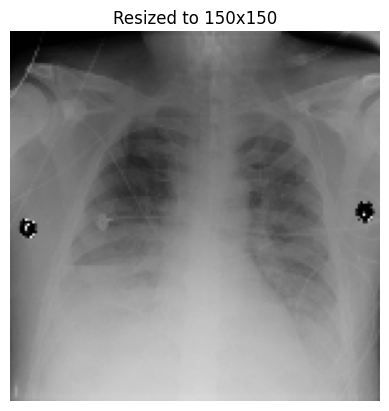

In [37]:
import cv2  # a library for image processing (resizing, etc.)

IMG_SIZE = 150  # we'll shrink every image to 150x150 pixels

def load_and_preprocess(patient_id, base_path):
    """Loads one DICOM image, resizes it, and normalizes pixel values."""
    dcm_path = f'{base_path}/stage_2_train_images/{patient_id}.dcm'
    dcm = pydicom.dcmread(dcm_path)
    img = dcm.pixel_array  # raw pixel values, shape (1024, 1024)
    
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # shrink to 150x150
    img_normalized = img_resized / 255.0  # scale pixel values from 0-255 down to 0-1
    
    return img_normalized

# Test it on one image
test_id = train_df['patientId'].iloc[0]
test_img = load_and_preprocess(test_id, base_path)

print("Shape after resize:", test_img.shape)
print("Pixel value range after normalize:", test_img.min(), "to", test_img.max())

plt.imshow(test_img, cmap='gray')
plt.title(f'Resized to {IMG_SIZE}x{IMG_SIZE}')
plt.axis('off')
plt.show()

In [38]:
import tensorflow as tf
from tensorflow.keras.utils import Sequence

class XrayDataGenerator(Sequence):
    """Feeds the model batches of X-ray images + labels, loading them on-demand."""
    
    def __init__(self, dataframe, base_path, image_folder, batch_size=32, img_size=150, shuffle=True):
        self.df = dataframe.reset_index(drop=True)
        self.base_path = base_path
        self.image_folder = image_folder  # 'stage_2_train_images' for all our splits, since val/test also come from the "train" folder in this dataset
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.on_epoch_end()  # shuffles order once at the start
    
    def __len__(self):
        # Tells Keras how many batches make up one full pass through the data
        return int(np.ceil(len(self.df) / self.batch_size))
    
    def __getitem__(self, index):
        # Grabs the rows for this specific batch
        batch_df = self.df.iloc[index * self.batch_size : (index + 1) * self.batch_size]
        
        images = []
        labels = []
        for _, row in batch_df.iterrows():
            dcm_path = f"{self.base_path}/{self.image_folder}/{row['patientId']}.dcm"
            dcm = pydicom.dcmread(dcm_path)
            img = cv2.resize(dcm.pixel_array, (self.img_size, self.img_size))
            img = img / 255.0
            images.append(img)
            labels.append(row['Target'])
        
        # Add a "channel" dimension: CNNs expect (height, width, channels) even for grayscale (channels=1)
        images = np.array(images).reshape(-1, self.img_size, self.img_size, 1)
        labels = np.array(labels)
        
        return images, labels
    
    def on_epoch_end(self):
        # Called automatically after every full pass through the data - reshuffles order if needed
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)

# Create one generator for each split
train_gen = XrayDataGenerator(train_df, base_path, 'stage_2_train_images', batch_size=32, shuffle=True)
val_gen = XrayDataGenerator(val_df, base_path, 'stage_2_train_images', batch_size=32, shuffle=False)
test_gen = XrayDataGenerator(test_df, base_path, 'stage_2_train_images', batch_size=32, shuffle=False)

# Quick sanity check: pull one batch and check its shape
sample_images, sample_labels = train_gen[0]
print("Batch images shape:", sample_images.shape)
print("Batch labels shape:", sample_labels.shape)
print("Sample labels:", sample_labels)

Batch images shape: (32, 150, 150, 1)
Batch labels shape: (32,)
Sample labels: [0 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 1]


In [39]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_df['Target'].values)
class_weight_dict = {0: weights[0], 1: weights[1]}

print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.6454042847270214), 1: np.float64(2.219344106463878)}


In [40]:
from tensorflow.keras import layers, models

def build_simple_cnn(img_size=150):
    model = models.Sequential([
        layers.Input(shape=(img_size, img_size, 1)),
        
        layers.Conv2D(16, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

simple_cnn = build_simple_cnn()
simple_cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 148, 148, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     2,654,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,659,137 (10.14 MB)

 Trainable params: 2,659,137 (10.14 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
simple_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

history_simple = simple_cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weight_dict
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
584/584 ━━━━━━━━━━━━━━━━━━━━ 134s 224ms/step - accuracy: 0.6992 - auc: 0.7630 - loss: 0.5854 - val_accuracy: 0.7782 - val_auc: 0.8037 - val_loss: 0.4709
Epoch 2/5
584/584 ━━━━━━━━━━━━━━━━━━━━ 118s 203ms/step - accuracy: 0.7213 - auc: 0.7893 - loss: 0.5594 - val_accuracy: 0.7177 - val_auc: 0.8087 - val_loss: 0.5669
Epoch 3/5
584/584 ━━━━━━━━━━━━━━━━━━━━ 119s 203ms/step - accuracy: 0.7312 - auc: 0.8069 - loss: 0.5387 - val_accuracy: 0.7372 - val_auc: 0.8111 - val_loss: 0.5539
Epoch 4/5
584/584 ━━━━━━━━━━━━━━━━━━━━ 119s 204ms/step - accuracy: 0.7527 - auc: 0.8242 - loss: 0.5188 - val_accuracy: 0.7834 - val_auc: 0.8094 - val_loss: 0.4597
Epoch 5/5
584/584 ━━━━━━━━━━━━━━━━━━━━ 120s 205ms/step - accuracy: 0.7612 - auc: 0.8422 - loss: 0.4929 - val_accuracy: 0.6830 - val_auc: 0.8144 - val_loss: 0.6059


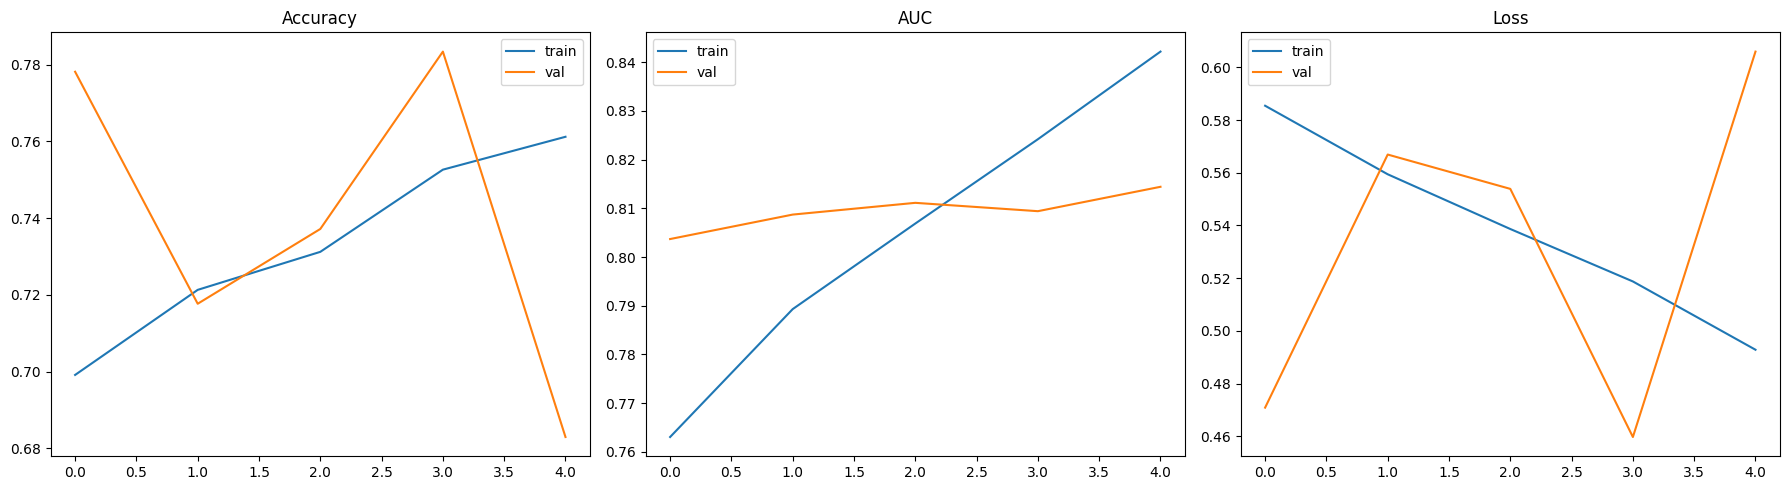

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_simple.history['accuracy'], label='train')
axes[0].plot(history_simple.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history_simple.history['auc'], label='train')
axes[1].plot(history_simple.history['val_auc'], label='val')
axes[1].set_title('AUC')
axes[1].legend()

axes[2].plot(history_simple.history['loss'], label='train')
axes[2].plot(history_simple.history['val_loss'], label='val')
axes[2].set_title('Loss')
axes[2].legend()

plt.tight_layout()
plt.show()


In [43]:
def build_deep_cnn(img_size=150):
    model = models.Sequential([
        layers.Input(shape=(img_size, img_size, 1)),

        layers.Conv2D(32, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

deep_cnn = build_deep_cnn()
deep_cnn.summary()

deep_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

history_deep = deep_cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weight_dict
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,044,737 (3.99 MB)

 Trainable params: 1,044,033 (3.98 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/5
584/584 ━━━━━━━━━━━━━━━━━━━━ 134s 218ms/step - accuracy: 0.6926 - auc: 0.7425 - loss: 0.6540 - val_accuracy: 0.7732 - val_auc: 0.7960 - val_loss: 0.5050
Epoch 2/5
584/584 ━━━━━━━━━━━━━━━━━━━━ 122s 208ms/step - accuracy: 0.7301 - auc: 0.7849 - loss: 0.5706 - val_accuracy: 0.7419 - val_auc: 0.8170 - val_loss: 0.5366
Epoch 3/5
584/584 ━━━━━━━━━━━━━━━━━━━━ 122s 208ms/step - accuracy: 0.7327 - auc: 0.7942 - loss: 0.5610 - val_accuracy: 0.7904 - val_auc: 0.8209 - val_loss: 0.4751
Epoch 4/5
584/584 ━━━━━━━━━━━━━━━━━━━━ 122s 210ms/step - accuracy: 0.7529 - auc: 0.8040 - loss: 0.5505 - val_accuracy: 0.7664 - val_auc: 0.8223 - val_loss: 0.5033
Epoch 5/5
584/584 ━━━━━━━━━━━━━━━━━━━━ 121s 208ms/step - accuracy: 0.7446 - auc: 0.8076 - loss: 0.5453 - val_accuracy: 0.7952 - val_auc: 0.7871 - val_loss: 0.4657


In [44]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

class XrayDataGeneratorRGB(Sequence):
    """Same as before, but converts grayscale to 3-channel for transfer learning models."""

    def __init__(self, dataframe, base_path, image_folder, batch_size=32, img_size=150, shuffle=True):
        self.df = dataframe.reset_index(drop=True)
        self.base_path = base_path
        self.image_folder = image_folder
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_df = self.df.iloc[index * self.batch_size : (index + 1) * self.batch_size]

        images = []
        labels = []
        for _, row in batch_df.iterrows():
            dcm_path = f"{self.base_path}/{self.image_folder}/{row['patientId']}.dcm"
            dcm = pydicom.dcmread(dcm_path)
            img = cv2.resize(dcm.pixel_array, (self.img_size, self.img_size))
            img_rgb = np.stack([img]*3, axis=-1)  # grayscale -> 3 channel
            images.append(img_rgb)
            labels.append(row['Target'])

        images = np.array(images, dtype=np.float32)
        images = preprocess_input(images)  # MobileNetV2's own normalization
        labels = np.array(labels)

        return images, labels

    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)

train_gen_rgb = XrayDataGeneratorRGB(train_df, base_path, 'stage_2_train_images', batch_size=32, shuffle=True)
val_gen_rgb = XrayDataGeneratorRGB(val_df, base_path, 'stage_2_train_images', batch_size=32, shuffle=False)
test_gen_rgb = XrayDataGeneratorRGB(test_df, base_path, 'stage_2_train_images', batch_size=32, shuffle=False)

# Build transfer learning model
base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # freeze pretrained layers first

transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

transfer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

transfer_model.summary()

history_transfer = transfer_model.fit(
    train_gen_rgb,
    validation_data=val_gen_rgb,
    epochs=5,
    class_weight=class_weight_dict
)

/tmp/ipykernel_58/3012141257.py:47: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/5
584/584 ━━━━━━━━━━━━━━━━━━━━ 144s 233ms/step - accuracy: 0.7093 - auc: 0.7923 - loss: 0.5566 - val_accuracy: 0.7647 - val_auc: 0.8407 - val_loss: 0.4604
Epoch 2/5
584/584 ━━━━━━━━━━━━━━━━━━━━ 125s 214ms/step - accuracy: 0.7264 - auc: 0.8194 - loss: 0.5237 - val_accuracy: 0.7295 - val_auc: 0.8472 - val_loss: 0.5251
Epoch 3/5
584/584 ━━━━━━━━━━━━━━━━━━━━ 123s 211ms/step - accuracy: 0.7324 - auc: 0.8287 - loss: 0.5132 - val_accuracy: 0.7454 - val_auc: 0.8467 - val_loss: 0.5056
Epoch 4/5
584/584 ━━━━━━━━━━━━━━━━━━━━ 123s 211ms/step - accuracy: 0.7407 - auc: 0.8310 - loss: 0.5080 - val_accuracy: 0.7399 - val_auc: 0.8481 - val_loss: 0.4854
Epoch 5/5
584/584 ━━━━━━━━━━━━━━━━━━━━ 121s 207ms/step - accuracy: 0.7467 - auc: 0.8354 - loss: 0.5042 - val_accuracy: 0.7050 - val_auc: 0.8484 - val_loss: 0.5716


In [45]:
print("=== SIMPLE CNN ===")
simple_results = simple_cnn.evaluate(test_gen)
print(dict(zip(simple_cnn.metrics_names, simple_results)))

print("\n=== DEEP CNN ===")
deep_results = deep_cnn.evaluate(test_gen)
print(dict(zip(deep_cnn.metrics_names, deep_results)))

print("\n=== TRANSFER LEARNING (MobileNetV2) ===")
transfer_results = transfer_model.evaluate(test_gen_rgb)
print(dict(zip(transfer_model.metrics_names, transfer_results)))

=== SIMPLE CNN ===
126/126 ━━━━━━━━━━━━━━━━━━━━ 24s 191ms/step - accuracy: 0.6822 - auc: 0.8054 - loss: 0.6054
{'loss': 0.6053694486618042, 'compile_metrics': 0.6822383403778076}

=== DEEP CNN ===
126/126 ━━━━━━━━━━━━━━━━━━━━ 21s 166ms/step - accuracy: 0.7914 - auc: 0.7810 - loss: 0.4672
{'loss': 0.4671628177165985, 'compile_metrics': 0.7914064526557922}

=== TRANSFER LEARNING (MobileNetV2) ===
126/126 ━━━━━━━━━━━━━━━━━━━━ 22s 171ms/step - accuracy: 0.7005 - auc: 0.8377 - loss: 0.5823
{'loss': 0.5823121666908264, 'compile_metrics': 0.7004746198654175}


In [46]:
transfer_model.save('/kaggle/working/pneumonia_model.keras')
print("Model saved!")

Model saved!


In [47]:
!pip install tf-keras tensorflowjs --quiet

In [49]:
!pip install tensorflow==2.19.0 tensorflowjs tf-keras --quiet

In [50]:
import tensorflowjs as tfjs
tfjs.converters.save_keras_model(transfer_model, '/kaggle/working/tfjs_model')
print("Converted! Files are in /kaggle/working/tfjs_model")

ImportError: /usr/local/lib/python3.12/dist-packages/tensorflow/python/data/experimental/service/../../../_pywrap_tensorflow_internal.so: undefined symbol: _ZN10tensorflow10RunOptionsC2EPN6google8protobuf5ArenaEb

In [51]:
import cv2

# Grab one normal and one pneumonia example from your test set
normal_id = test_df[test_df['Target'] == 0]['patientId'].iloc[0]
pneumonia_id = test_df[test_df['Target'] == 1]['patientId'].iloc[0]

# Convert and save both as PNG
normal_dcm = pydicom.dcmread(f'{base_path}/stage_2_train_images/{normal_id}.dcm')
pneumonia_dcm = pydicom.dcmread(f'{base_path}/stage_2_train_images/{pneumonia_id}.dcm')

cv2.imwrite('/kaggle/working/sample_normal.png', normal_dcm.pixel_array)
cv2.imwrite('/kaggle/working/sample_pneumonia.png', pneumonia_dcm.pixel_array)

print("Saved sample_normal.png (true label: Normal)")
print("Saved sample_pneumonia.png (true label: Pneumonia)")

Saved sample_normal.png (true label: Normal)
Saved sample_pneumonia.png (true label: Pneumonia)


In [53]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

for name, model, gen, df in [
    ("Simple CNN", simple_cnn, test_gen, test_df),
    ("Deep CNN", deep_cnn, test_gen, test_df),
    ("MobileNetV2", transfer_model, test_gen_rgb, test_df),
]:
    y_true = df['Target'].values
    y_pred_proba = model.predict(gen, verbose=1)
    y_pred = (y_pred_proba > 0.5).astype(int)

    print(f"\n=== {name} ===")
    print(confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred, target_names=["Normal", "Pneumonia"]))

126/126 ━━━━━━━━━━━━━━━━━━━━ 24s 186ms/step

=== Simple CNN ===
[[1979 1122]
 [ 150  752]]
              precision    recall  f1-score   support

      Normal       0.93      0.64      0.76      3101
   Pneumonia       0.40      0.83      0.54       902

    accuracy                           0.68      4003
   macro avg       0.67      0.74      0.65      4003
weighted avg       0.81      0.68      0.71      4003

126/126 ━━━━━━━━━━━━━━━━━━━━ 22s 170ms/step

=== Deep CNN ===
[[2816  285]
 [ 550  352]]
              precision    recall  f1-score   support

      Normal       0.84      0.91      0.87      3101
   Pneumonia       0.55      0.39      0.46       902

    accuracy                           0.79      4003
   macro avg       0.69      0.65      0.66      4003
weighted avg       0.77      0.79      0.78      4003

126/126 ━━━━━━━━━━━━━━━━━━━━ 30s 207ms/step

=== MobileNetV2 ===
[[2035 1066]
 [ 133  769]]
              precision    recall  f1-score   support

      Normal       